In [3]:
import  pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
matches=pd.read_csv('matches.csv')
deliveries=pd.read_csv('deliveries.csv')

In [7]:
print("shape:",matches.shape)

shape: (1095, 20)


In [8]:
print("columns:",matches.columns.tolist())

columns: ['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']


In [14]:
print("\nFirst 5 rows :",matches.head())
print("\nLast 5 rows:",matches.tail())


First 5 rows :        id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  2008-04-18     League     BB McCullum   
1  335983  2007/08  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984  2007/08       Delhi  2008-04-19     League     MF Maharoof   
3  335985  2007/08      Mumbai  2008-04-20     League      MV Boucher   
4  335986  2007/08     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
2                            Feroz Shah Kotla             Delhi Daredevils   
3                            Wankhede Stadium               Mumbai Indians   
4                                Eden Gardens        Kolkata Knight Riders   

                         team2                  toss_winner toss_decision  \

In [15]:
print("\nMissing values:",matches.isnull().sum())


Missing values: id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


In [16]:
print("\nbasic stats:",matches.describe())


basic stats:                  id  result_margin  target_runs  target_overs
count  1.095000e+03    1076.000000  1092.000000   1092.000000
mean   9.048283e+05      17.259294   165.684066     19.759341
std    3.677402e+05      21.787444    33.427048      1.581108
min    3.359820e+05       1.000000    43.000000      5.000000
25%    5.483315e+05       6.000000   146.000000     20.000000
50%    9.809610e+05       8.000000   166.000000     20.000000
75%    1.254062e+06      20.000000   187.000000     20.000000
max    1.426312e+06     146.000000   288.000000     20.000000


In [17]:
matches=matches.dropna(subset=['winner'])

In [18]:
print("season:",sorted(matches['season'].unique()))

season: ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024']


In [19]:
print("teams:",matches['team1'].unique())

teams: <StringArray>
['Royal Challengers Bangalore',             'Kings XI Punjab',
            'Delhi Daredevils',              'Mumbai Indians',
       'Kolkata Knight Riders',            'Rajasthan Royals',
             'Deccan Chargers',         'Chennai Super Kings',
        'Kochi Tuskers Kerala',               'Pune Warriors',
         'Sunrisers Hyderabad',               'Gujarat Lions',
     'Rising Pune Supergiants',      'Rising Pune Supergiant',
              'Delhi Capitals',                'Punjab Kings',
        'Lucknow Super Giants',              'Gujarat Titans',
 'Royal Challengers Bengaluru']
Length: 19, dtype: str


C:\Users\S Harika\AppData\Local\Temp\ipykernel_17044\1974854940.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=team_wins.values,y=team_wins.index,palette='viridis')


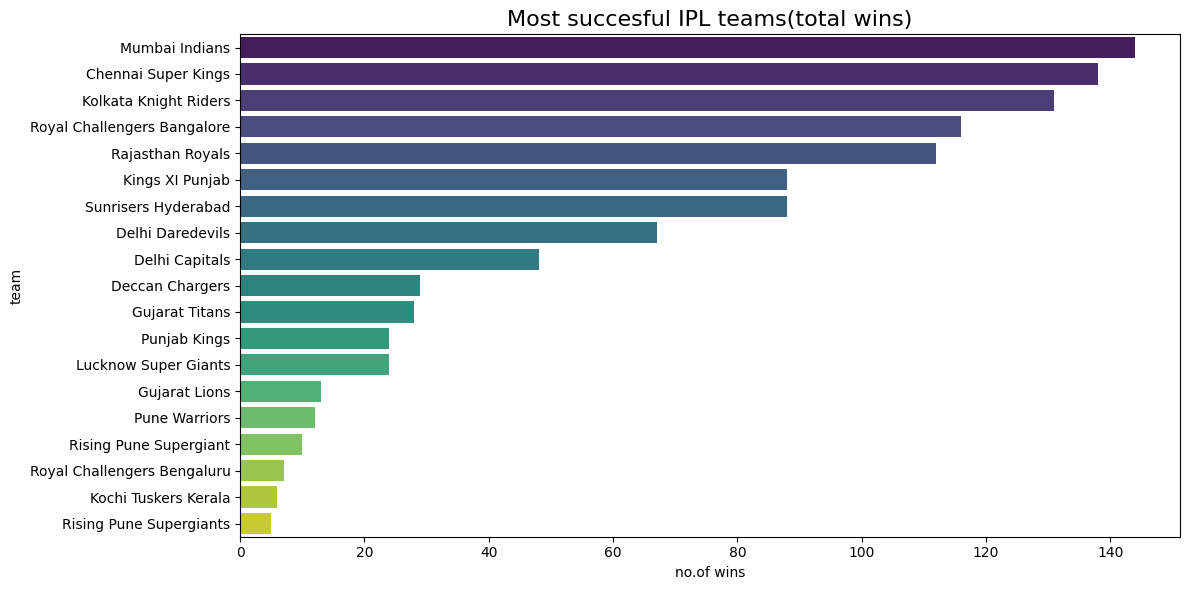

Insight:MI have the most wins in IPL history


In [22]:
plt.figure(figsize=(12,6))
team_wins=matches['winner'].value_counts()
sns.barplot(x=team_wins.values,y=team_wins.index,palette='viridis')
plt.title('Most succesful IPL teams(total wins)',fontsize=16)
plt.xlabel('no.of wins')
plt.ylabel('team')
plt.tight_layout()
plt.savefig('chart1_team_wins.png')
plt.show()
print('Insight:MI have the most wins in IPL history')

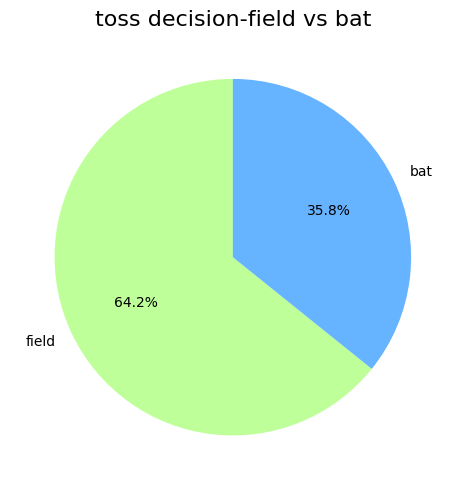

Insight:Most captains choose to field after winning toss


In [30]:
plt.figure(figsize=(8,5))
toss=matches['toss_decision'].value_counts()
plt.pie(toss.values,labels=toss.index,autopct='%1.1f%%',colors=["#beff99ff",'#66b3ff'],startangle=90)
plt.title('toss decision-field vs bat',fontsize=16)
plt.tight_layout()
plt.savefig('chart2_toss_decision.png')
plt.show()
print("Insight:Most captains choose to field after winning toss")

C:\Users\S Harika\AppData\Local\Temp\ipykernel_17044\3374667536.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['toss winner lost','toss winner won'],y=toss_win.values,palette='coolwarm')


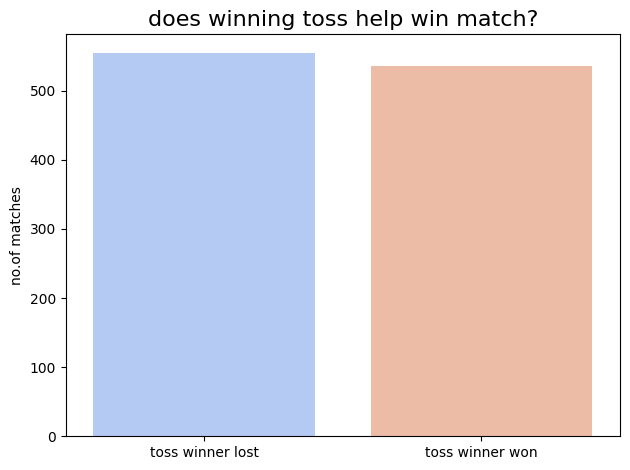

Insight:winning toss gives only slight advantage


In [31]:
matches['toss_match_winner']=(matches['toss_winner']==matches['winner'])
plt.Figure(figsize=(7,5))
toss_win=matches['toss_match_winner'].value_counts()
sns.barplot(x=['toss winner lost','toss winner won'],y=toss_win.values,palette='coolwarm')
plt.title('does winning toss help win match?',fontsize=16)
plt.ylabel('no.of matches')
plt.tight_layout()
plt.savefig('chart3_toss_effect.png')
plt.show()
print("Insight:winning toss gives only slight advantage")

C:\Users\S Harika\AppData\Local\Temp\ipykernel_17044\105389220.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_players.values,y=top_players.index,palette='magma')


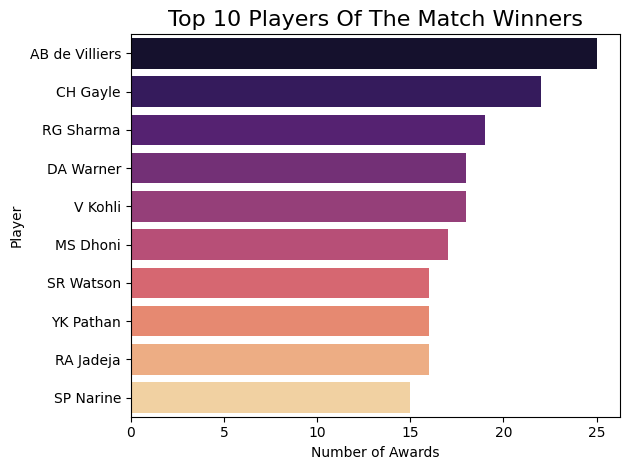

Insight: AB de Villiers and CH Gayle dominate awards


In [33]:
plt.Figure(figsize=(12,6))
top_players=matches['player_of_match'].value_counts().head(10)
sns.barplot(x=top_players.values,y=top_players.index,palette='magma')
plt.title('Top 10 Players Of The Match Winners',fontsize=16)
plt.xlabel('Number of Awards')
plt.ylabel('Player')
plt.tight_layout()
plt.savefig('chart4_top_players.png')
plt.show()
print("Insight: AB de Villiers and CH Gayle dominate awards")

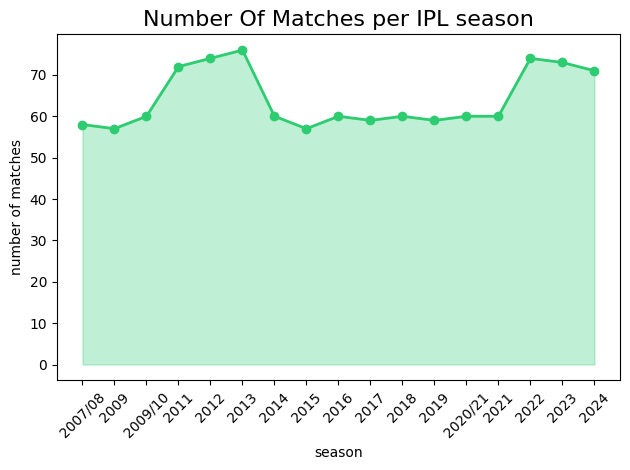

Insight:IPL expanded significantly from 2011 onwards


In [38]:
plt.Figure(figsize=(12,5))
matches_per_season=matches.groupby('season').size()
plt.plot(matches_per_season.index,matches_per_season.values,marker='o',linewidth=2,color='#2ecc71')
plt.fill_between(matches_per_season.index,matches_per_season.values,alpha=0.3,color='#2ecc71')
plt.title('Number Of Matches per IPL season',fontsize=16)
plt.xlabel('season')
plt.ylabel('number of matches')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart5_matches_per_season.png')
plt.show()
print("Insight:IPL expanded significantly from 2011 onwards")

C:\Users\S Harika\AppData\Local\Temp\ipykernel_17044\688512798.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scorers.values, y=top_scorers.index,


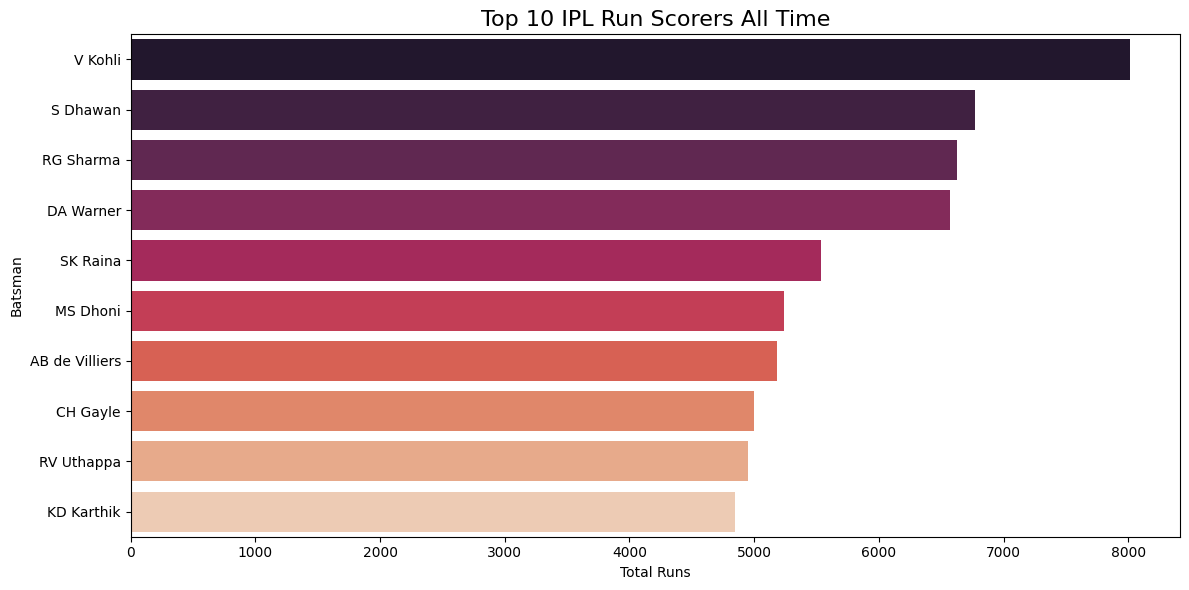

Insight: Virat Kohli is the all-time leading run scorer


In [43]:
plt.figure(figsize=(12,6))
top_scorers = deliveries.groupby('batter')['batsman_runs']\
              .sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_scorers.values, y=top_scorers.index,
            palette='rocket')
plt.title('Top 10 IPL Run Scorers All Time', fontsize=16)
plt.xlabel('Total Runs')
plt.ylabel('Batsman')
plt.tight_layout()
plt.savefig('chart6_top_scorers.png')
plt.show()
print("Insight: Virat Kohli is the all-time leading run scorer")

In [44]:
print(deliveries.columns.tolist())
print(deliveries.head(2))

['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']
   match_id  inning           batting_team                 bowling_team  over  \
0    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
1    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   

   ball       batter   bowler  non_striker  batsman_runs  extra_runs  \
0     1   SC Ganguly  P Kumar  BB McCullum             0           1   
1     2  BB McCullum  P Kumar   SC Ganguly             0           0   

   total_runs extras_type  is_wicket player_dismissed dismissal_kind fielder  
0           1     legbyes          0              NaN            NaN     NaN  
1           0         NaN          0              NaN            NaN     NaN  


In [ ]:
matches.to_csv('matches_clean.csv', index=False)
team_summary = pd.DataFrame({
    'Team': matches['winner'].value_counts().index,
    'Wins': matches['winner'].value_counts().values
})
team_summary.to_csv('team_summary.csv', index=False)

print("Files saved! Ready for Power BI.")

Files saved! Ready for Power BI.
